LEt's use the PCA as input for Kmeans which is going to make us find the different states of the market

In [1]:
# Cell 1 — Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.3f}".format)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["figure.dpi"] = 100

np.random.seed(42)
print("Setup OK")



Setup OK


In [2]:
# Cell 2 — Load PCA scores (for clustering) + master dataset (for DFL analysis)

pca_scores = pd.read_pickle("../data/processed/pca_scores.pkl")
df = pd.read_pickle("../data/master_dataset.pkl")

print(f"PCA scores : {pca_scores.shape}  ({pca_scores.index.min().date()} → {pca_scores.index.max().date()})")
print(f"Master     : {df.shape}")
print()

# Align the DFL onto the PCA-scores dates (clustering window)
dfl = df.loc[pca_scores.index, "DFL"]
print(f"DFL aligned on clustering window: {dfl.notna().sum()} non-NaN values")
print()
print(pca_scores.head(3))

PCA scores : (3035, 5)  (2014-01-30 → 2026-05-06)
Master     : (3055, 43)

DFL aligned on clustering window: 3015 non-NaN values

             PC1    PC2    PC3    PC4   PC5
date                                       
2014-01-30 0.170 -1.728 -0.338 -0.227 2.991
2014-01-31 0.236 -1.795 -0.100 -0.558 2.481
2014-02-03 0.304 -1.405 -0.241  0.111 2.929


We made sure PCA and DFL have the same dates

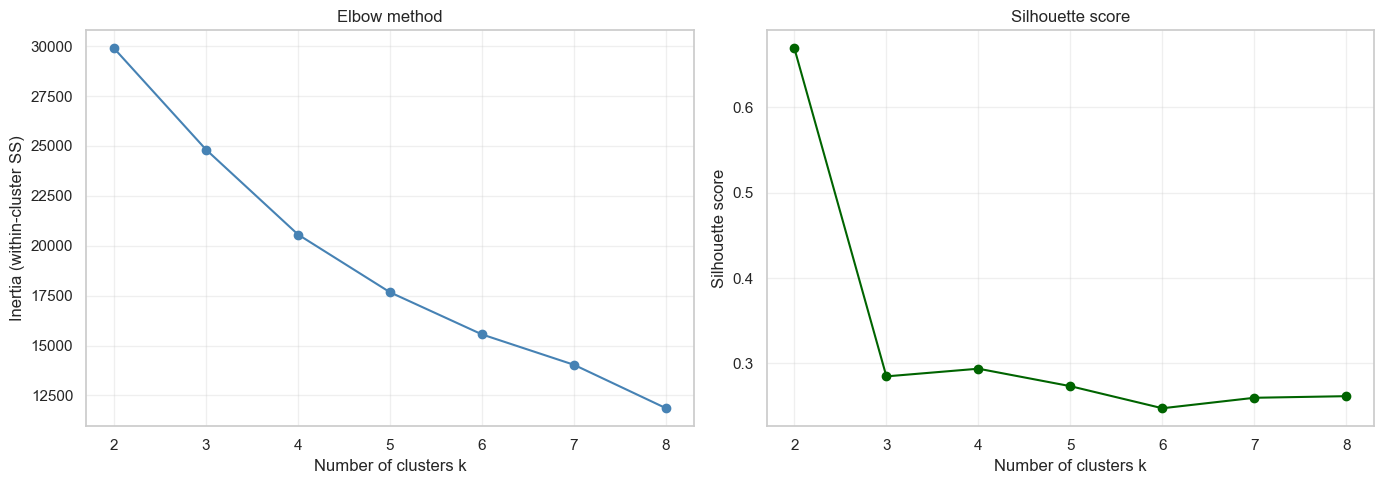

 k |    inertia | silhouette
------------------------------
 2 |      29893 |      0.669
 3 |      24817 |      0.285
 4 |      20561 |      0.294
 5 |      17666 |      0.273
 6 |      15555 |      0.248
 7 |      14033 |      0.260
 8 |      11857 |      0.262


In [3]:
# Cell 3 — Choose the number of regimes: elbow method + silhouette score

X = pca_scores.values   # the 5 PCA components per day

k_range = range(2, 9)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

# Plot both diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(list(k_range), inertias, marker="o", color="steelblue")
ax.set_xlabel("Number of clusters k")
ax.set_ylabel("Inertia (within-cluster SS)")
ax.set_title("Elbow method")
ax.grid(alpha=0.3)  

ax = axes[1]
ax.plot(list(k_range), silhouettes, marker="o", color="darkgreen")
ax.set_xlabel("Number of clusters k")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette score")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"{'k':>2} | {'inertia':>10} | {'silhouette':>10}")
print("-" * 30)
for k, i, s in zip(k_range, inertias, silhouettes):
    print(f"{k:>2} | {i:>10.0f} | {s:>10.3f}")

In [4]:
# Cell 4 — Fit K-means with k=4 and assign a regime label to each day

k = 4
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
regime_labels = kmeans.fit_predict(pca_scores.values)

# Attach labels to the dates
regimes = pd.Series(regime_labels, index=pca_scores.index, name="regime")

print(f"K-means fitted with k={k}\n")
print("Days per regime:")
counts = regimes.value_counts().sort_index()
for r, n in counts.items():
    print(f"  Regime {r}: {n:>5} days ({n / len(regimes) * 100:.1f}%)")


K-means fitted with k=4

Days per regime:
  Regime 0:  1964 days (64.7%)
  Regime 1:   138 days (4.5%)
  Regime 2:    12 days (0.4%)
  Regime 3:   921 days (30.3%)


Regime centroids (mean position on each PC):

            PC1    PC2     PC3    PC4    PC5
Regime 0  0.380 -0.380  -0.140  0.010  0.140
Regime 1  7.770  1.060   2.180 -0.890  0.880
Regime 2 17.400  6.730 -13.320  1.880 -4.140
Regime 3 -2.200  0.560   0.150  0.100 -0.380


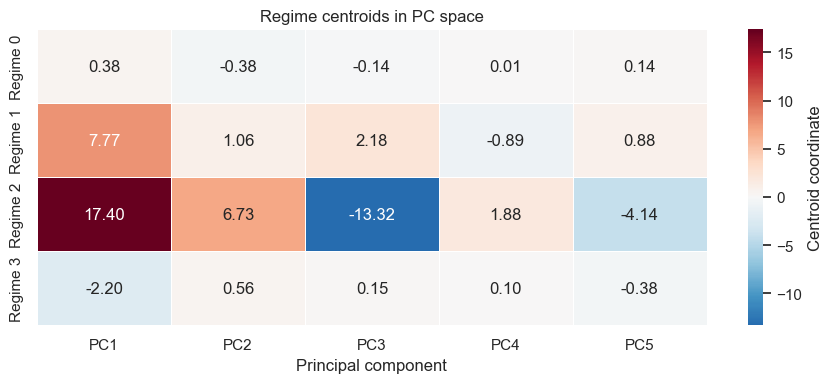

In [5]:

# Cell 5 — Interpret regimes via their centroids in PC space

centroids = pd.DataFrame(
    kmeans.cluster_centers_,  
    columns=pca_scores.columns,
    index=[f"Regime {i}" for i in range(k)],
)
print("Regime centroids (mean position on each PC):\n")
print(centroids.round(2))

# Heatmap
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(centroids, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Centroid coordinate"}, ax=ax)
ax.set_title("Regime centroids in PC space")
ax.set_xlabel("Principal component")
plt.tight_layout()  
plt.show()

## Regime interpretation

The four regimes order **monotonically along PC1** (global curve tightness, the
dominant factor at 43% of variance), forming a natural gradient of physical market
tightness:

| Regime | Name | PC1 (tightness) | Frequency |
|---|---|---|---|   
| 3 | Contango / oversupply | −2.20 | 30.3% |
| 0 | Calm / normal | +0.38 | 64.7% |
| 1 | Physical tightness | +7.77 | 4.5% |
| 2 | Crisis (extreme) | +17.40 | 0.4% (12 days) |

**Regime 0 — Calm / normal (65%)**: near the origin on all components. Mild
backwardation, low volatility (PC2 negative). The baseline market state.

**Regime 3 — Contango / oversupply (30%)**: PC1 is negative → the curve is in
contango (well-supplied, "heavy" physical market). The bearish-physical counterpart
of the calm regime.

**Regime 1 — Physical tightness (4.5%)**: strong backwardation (PC1 = +7.8),
moderate volatility, Brent rich vs Dubai (PC3 = +2.2). A tight physical market
without full macro panic.

**Regime 2 — Crisis (0.4%, 12 days)**: every dimension is extreme simultaneously —
extreme backwardation (PC1 = +17.4), extreme volatility / risk-off (PC2 = +6.7),
violent East-West dislocation (PC3 = −13.3), macro shock in progress (PC4 = +1.9).
These are the COVID / Russia / April-2026 crisis days.

**Notable detail — PC3 flips sign**: in the ordinary tightness regime (1), PC3 is
positive (+2.2, Brent rich vs Dubai); in the crisis regime (2) it is strongly
negative (−13.3). The Brent–Dubai geographic relationship behaves *qualitatively
differently* during extreme crises than during ordinary physical tightness — a
subtle signal the VaR model can exploit.

The regime structure is economically coherent: it maps onto how a physical trader
reads the market — from oversupplied (contango), through normal, to tight
(backwardation), to crisis. The regimes were found **without ever looking at the
DFL** (the target was excluded from clustering), so the next step validates whether
they separate the DFL distribution out-of-sample.


=== DFL distribution per regime ===

Regime                         N    mean     std      p1     p99     min     max
--------------------------------------------------------------------------------
0 Calm                      1954   +0.28    1.36   -2.45   +4.10   -5.13   +7.59
1 Physical tightness         138   +6.47    7.54   -1.92  +34.50   -2.06  +36.05
2 East-West dislocation       12   +3.86    3.82   -0.47   +9.96   -0.52  +10.11
3 Contango/oversupply        911   -1.29    1.42   -7.93   +1.05  -10.81   +1.54


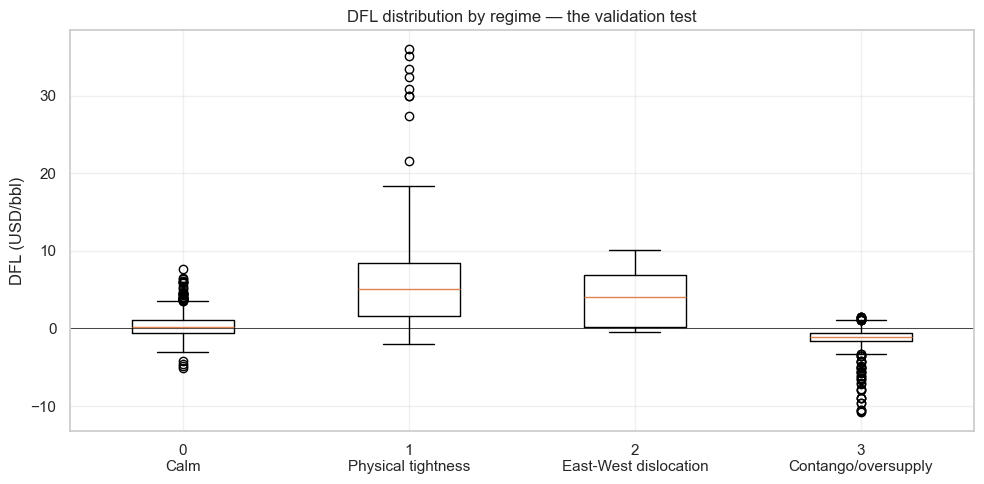

In [12]:
# Cell 6 — Validation: does the DFL distribution differ across regimes?

regime_names = {
      0: "Calm",
      1: "Physical tightness",
      2: "East-West dislocation",
      3: "Contango/oversupply",
}

# Combine regime labels with DFL (drop the ~20 Platts-holiday NaN)
val = pd.DataFrame({"regime": regimes, "DFL": dfl}).dropna()

print("=== DFL distribution per regime ===\n")
print(f"{'Regime':<26}{'N':>6}{'mean':>8}{'std':>8}{'p1':>8}{'p99':>8}{'min':>8}{'max':>8}")
print("-" * 80)
for r in sorted(val["regime"].unique()):
    sub = val.loc[val["regime"] == r, "DFL"]
    name = f"{r} {regime_names[r]}"
    print(f"{name:<26}{len(sub):>6}{sub.mean():>+8.2f}{sub.std():>8.2f}"
        f"{sub.quantile(0.01):>+8.2f}{sub.quantile(0.99):>+8.2f}"
        f"{sub.min():>+8.2f}{sub.max():>+8.2f}")

# Boxplot of DFL by regime
fig, ax = plt.subplots(figsize=(10, 5))
order = sorted(val["regime"].unique())
data_by_regime = [val.loc[val["regime"] == r, "DFL"] for r in order]
tick_labels = [f"{r}\n{regime_names[r]}" for r in order]

ax.boxplot(data_by_regime, tick_labels=tick_labels, showfliers=True)
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("DFL (USD/bbl)")
ax.set_title("DFL distribution by regime — the validation test")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Inspect which dates fall in the two stress regimes (1 and 2)
for r in [1, 2]:
    dates = regimes[regimes == r].index
    print(f"\n=== Regime {r}: {len(dates)} days ({dates.min().date()} → {dates.max().date()}) ===")
    print("  Distribution by year:")
    yc = dates.year.value_counts().sort_index()
    for y, n in yc.items():
        print(f"    {y}: {n} days")

# Show the 12 days of the tiny regime explicitly
tiny = 2  # the 12-day regime
print(f"\n=== The {(regimes==tiny).sum()} days of Regime {tiny}, with their DFL ===")
tiny_dates = regimes[regimes == tiny].index
print(df.loc[tiny_dates, ["DFL", "brent_dated", "brent_l1", "wti_l1", "dubai_l1"]].round(2).to_string())


=== Regime 1: 138 days (2022-02-24 → 2026-05-06) ===
  Distribution by year:
    2022: 106 days
    2026: 32 days

=== Regime 2: 12 days (2026-03-10 → 2026-03-25) ===
  Distribution by year:
    2026: 12 days

=== The 12 days of Regime 2, with their DFL ===
              DFL  brent_dated  brent_l1  wti_l1  dubai_l1
date                                                      
2026-03-10  0.140       87.940    87.800  83.450   115.200
2026-03-11 -0.520       91.460    91.980  87.250   119.550
2026-03-12  0.200      100.660   100.460  95.730   134.400
2026-03-13  0.330      103.470   103.140  98.710   145.510
2026-03-16  3.480      103.700   100.210  93.500   153.240
2026-03-17 -0.110      103.310   103.420  96.210   157.660
2026-03-18  5.150      112.530   107.380  96.320   155.550
2026-03-19  8.780      117.440   108.650  96.140   166.800
2026-03-20  4.750      116.940   112.190  98.230   158.850
2026-03-23 10.110      110.040    99.940  88.130   169.750
2026-03-24  6.650      111.140   

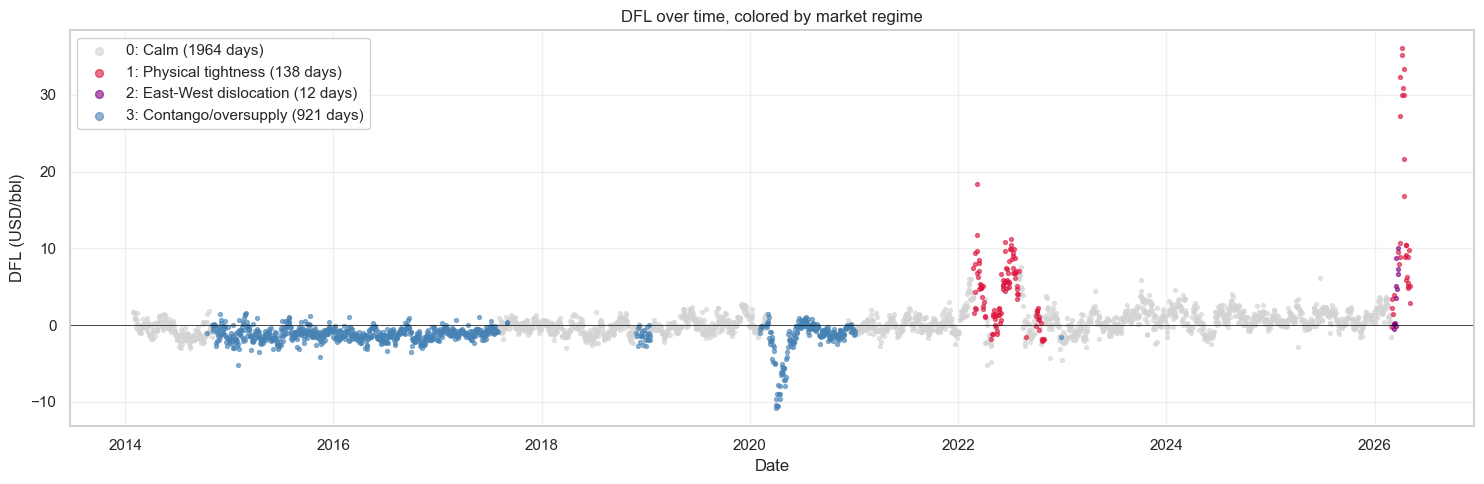

In [14]:
# Cell 7 — Timeline of the DFL, colored by regime

regime_colors = {
    0: "lightgray",    # Calm
    1: "crimson",      # Physical tightness
    2: "purple",       # East-West dislocation
    3: "steelblue",    # Contango / oversupply
}

fig, ax = plt.subplots(figsize=(15, 5))

for r in sorted(regimes.unique()):
    mask = regimes == r
    dates_r = regimes.index[mask]
    dfl_r = df.loc[dates_r, "DFL"]
    ax.scatter(dates_r, dfl_r, s=8, c=regime_colors[r], alpha=0.6,
                label=f"{r}: {regime_names[r]} ({mask.sum()} days)")

ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("DFL (USD/bbl)")
ax.set_xlabel("Date")
ax.set_title("DFL over time, colored by market regime")
ax.legend(loc="upper left", markerscale=2, framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Cell 8 — Save regime labels for the VaR model (notebook 04)

from pathlib import Path

out_dir = Path("../data/processed")
out_dir.mkdir(exist_ok=True)

# Save the regime label per date
regimes.to_frame().to_pickle(out_dir / "regime_labels.pkl")
regimes.to_frame().to_csv(out_dir / "regime_labels.csv")

print(f"Saved regime labels: {len(regimes)} days "
    f"({regimes.index.min().date()} → {regimes.index.max().date()})")
print(f"  → {out_dir}/regime_labels.pkl + .csv\n")
print("Regime mapping:")
for r, name in regime_names.items():
    print(f"  {r}: {name}")

Saved regime labels: 3035 days (2014-01-30 → 2026-05-06)
  → ../data/processed/regime_labels.pkl + .csv

Regime mapping:
  0: Calm
  1: Physical tightness
  2: East-West dislocation
  3: Contango/oversupply


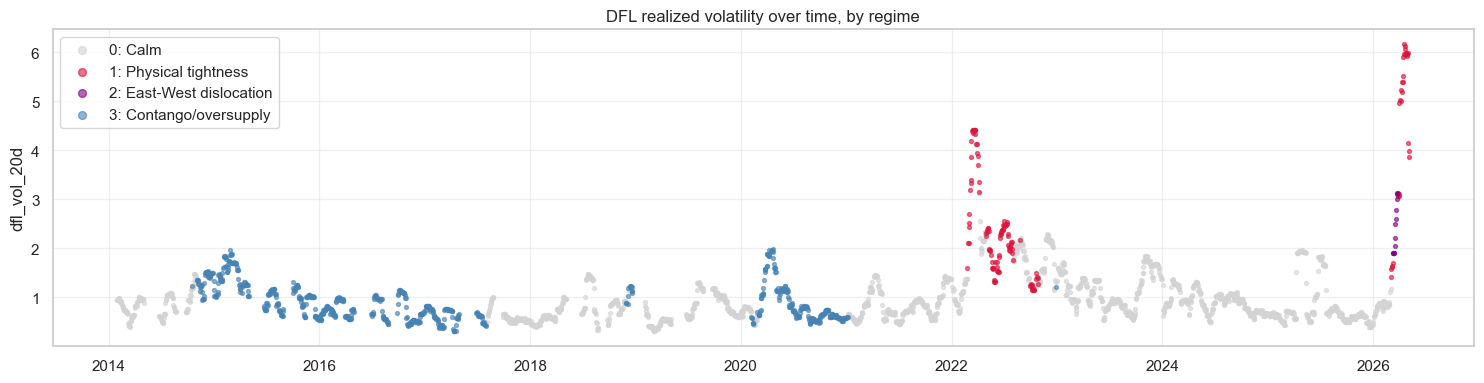

In [16]:
fig, ax = plt.subplots(figsize=(15, 4))
for r in sorted(regimes.unique()):
    mask = regimes == r
    ax.scatter(regimes.index[mask], df.loc[regimes.index[mask], "dfl_vol_20d"],
                s=8, c=regime_colors[r], alpha=0.6, label=f"{r}: {regime_names[r]}")
ax.set_ylabel("dfl_vol_20d")
ax.set_title("DFL realized volatility over time, by regime")
ax.legend(loc="upper left", markerscale=2)
ax.grid(alpha=0.3)  
plt.tight_layout()
plt.show()


▎ "Mes régimes sont structurels — dominés par la forme de courbe (PC1). Ils captent les chocs comme COVID ou l'Ukraine, mais ils peuvent rater une volatilité élevée 
▎ du DFL sans dislocation structurelle, comme en 2024. C'est pourquoi je ne m'arrête pas au régime : je superpose un modèle continu (XGBoost quantile) qui lit la 
▎ volatilité réalisée et ajuste la VaR finement, même à l'intérieur d'un régime calme. Le régime donne le contexte macro-structurel, le modèle continu donne la 
▎ précision."


ahh ok là on a fait un modèle discret du coup et xgboost nous fera un model continue?                                                                                

⏺ Exactement, c'est ça l'idée. Précisons ce que "discret vs continu" veut dire ici, parce que c'est le cœur de la différence.

Le modèle discret (baseline par régime)

Input  : le label de régime (une catégorie : 0, 1, 2 ou 3)
Output : 1 VaR par régime → seulement 4 valeurs possibles

C'est une table de correspondance :
régime Calm        → VaR = +$4.10   (TOUS les jours calmes ont cette valeur)
régime Tightness   → VaR = +$34.50  (TOUS les jours tightness ont cette valeur)
...

→ Quel que soit le jour, sa VaR ne peut prendre que 4 valeurs. Elle saute brutalement quand le régime change.

Le modèle continu (XGBoost)   

Input  : les features continues (vix=23.5, dfl_vol_20d=1.8, brent_l1_l2=2.3, ... + régime)
Output : une VaR fonction de ces features → ~une valeur différente par jour

C'est une fonction :
VaR(jour) = f(toutes les features du jour)

→ Chaque jour a sa VaR propre, qui varie continûment selon ses features. Deux jours "Calm" avec des vols différentes auront des VaR différentes.

Le contraste concret (l'exemple 2024)

┌─────────────────────────────────┬──────────────────────────────┬──────────────────────────────────┐
│                                 │        Modèle discret        │     Modèle continu (XGBoost)     │
├─────────────────────────────────┼──────────────────────────────┼──────────────────────────────────┤
│ Jour calme 2018 (vol DFL ≈ 0.7) │ VaR = +$4.10                 │ VaR ≈ +$3 (vol basse → resserre) │
├─────────────────────────────────┼──────────────────────────────┼──────────────────────────────────┤
│ Jour calme 2024 (vol DFL ≈ 2.0) │ VaR = +$4.10 (même valeur !) │ VaR ≈ +$6 (vol élevée → élargit) │
└─────────────────────────────────┴──────────────────────────────┴──────────────────────────────────┘

Le discret donne la même VaR aux deux jours (tous deux "Calm"). Le continu différencie : il voit que 2024 a une vol DFL plus élevée et élargit sa VaR en conséquence.
  C'est exactement l'angle mort qu'on a identifié sur ton plot.

⚠️  Une nuance technique (pour être précis)

XGBoost est fait d'arbres de décision, qui splittent sur des seuils. Donc techniquement son output n'est pas parfaitement lisse — c'est du piecewise-constant
(constant par morceaux) à granularité très fine. Mais comme il combine des centaines d'arbres avec des milliers de splits, l'output se comporte comme une fonction 
continue en pratique.

Donc :
Discret (4 valeurs)  →  XGBoost (des milliers de valeurs, ~1 par combinaison de features)

"Continu" au sens : beaucoup de valeurs fines qui s'adaptent aux inputs, vs 4 valeurs fixes. Pas continu au sens mathématique strict (dérivable), mais effectivement
continu en pratique.

En une phrase

▎ Le baseline par régime est une table de correspondance discrète (4 VaR possibles). XGBoost remplace cette table par une fonction des features continues : chaque 
▎ jour reçoit sa propre VaR, qui s'ajuste finement à son état réel (vol, courbe, etc.) — y compris à l'intérieur d'un même régime.

Tu as bien saisi la progression : discret (régime → VaR) → continu (features → VaR).


## Conclusion — Regime detection

### What we built

Starting from the 5 PCA components (notebook 02), we ran K-means and identified
**4 market regimes**. The number of clusters (k=4) was chosen by combining the elbow
method, the silhouette score, and economic interpretability — not by silhouette
alone (which favored k=2, a trivial calm-vs-stress split too coarse for useful VaR
conditioning).

The four regimes order **monotonically along PC1** (global curve tightness, 43% of
variance), forming a natural gradient of physical market tightness:

| Regime | Name | Frequency | DFL behavior |
|---|---|---|---|
| 3 | Contango / oversupply | 30.3% | downside risk (p1 = −$7.9, min −$10.8) |
| 0 | Calm / normal | 64.7% | tight around 0 (±$2) |
| 1 | Physical tightness | 4.5% | upside risk (p99 = +$34.5) |
| 2 | East-West dislocation | 0.4% (12 d) | moderate DFL, extreme Brent–Dubai gap |

### Validation — the key result

Crucially, the regimes were found **without ever using the DFL** (the target was
excluded from clustering to avoid circularity). Yet the DFL distribution turns out to
differ sharply across them, **asymmetrically**:
- **Contango** carries the DFL **downside** (COVID-2020 crash, DFL to −$10.8),
- **Physical tightness** carries the DFL **upside** (Russia-2022 and April-2026, DFL to +$36).

This asymmetric separation directly mirrors the strong positive skewness found in
notebook 01, and it empirically justifies the entire project thesis: **the DFL
distribution is regime-dependent, so a regime-conditional VaR is warranted.**

### Economic validity

The regimes map cleanly onto known market history, with no event labels given to the
model: the contango regime captures the 2014–2016 oversupply and the 2020 COVID crash;
the physical-tightness regime starts exactly on 2022-02-24 (Russia's invasion) and
recurs in April 2026; the East-West dislocation regime isolates 12 days of March 2026
when Dubai spiked to ~$169 against Brent ~$110 (Brent–Dubai EFS reaching −$70). The
unsupervised model effectively *rediscovered the market's crisis chronology*.

### Limitation — and why notebook 04 follows

Discrete regimes are a **coarse** conditioning variable. Because the clustering is
dominated by curve structure (PC1), periods of elevated DFL volatility without a curve
dislocation — e.g. 2024 — remain labelled "Calm", even though the DFL was more
dispersed than in the genuinely quiet 2018–2019. A single per-regime VaR would
under-react to such within-regime variation.

This is precisely the motivation for the next step. In notebook 04, XGBoost quantile
regression uses the **continuous features** (including realized volatility) on top of
the regime label, so it can widen or tighten the VaR *within* a regime — capturing the
finer variation that the discrete label misses.

### Output

The per-date regime labels are saved to `data/processed/regime_labels.pkl` and will be
used as a conditioning input to the conditional-VaR model in notebook 04.